Suppose we have a dataset of test scores: $[10, 12, 23, 23, 16, 23, 21, 16]$.
- The Mean ($\bar{x}$): Sum the numbers and divide by $n=8$. $$\bar{x} = 144 / 8 = 18.0$$
- The Variance ($s^2$): We measure how far each point is from $18.0$, square those differences, and average them. Note: We divide by $n-1$ (7) instead of $n$ (8) for samples. This is "Bessel’s Correction," and it accounts for the fact that a small sample usually underestimates the true population variability.
$$s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1} = 27.43$$
- The Standard Deviation ($s$): Take the square root of variance to get back to the original units (test scores).
$$s = \sqrt{27.43} \approx 5.24$$
- The Standard Error ($SE$): This tells us how much the mean would bounce around if we took a new sample of 8 people. It gets smaller as $n$ gets larger.
$$SE = \frac{s}{\sqrt{n}} = \frac{5.24}{\sqrt{8}} \approx 1.85$$
- The 95% Confidence Interval (CI): This is our "Safety Net." It says: "We are 95% sure the true population mean is within this range."
$$CI = \bar{x} \pm (t_{critical} \times SE) \approx 18.0 \pm 4.38 \rightarrow [13.62, 22.38]$$

Mean: 18.0, SD: 5.24, SE: 1.85


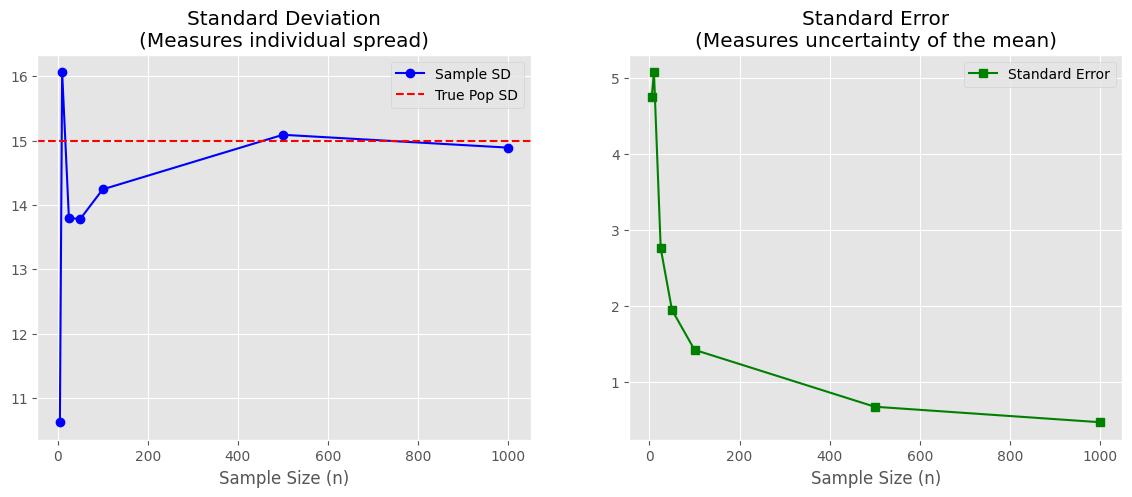

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Base Python Logic (Manual Math)
data = [10, 12, 23, 23, 16, 23, 21, 16]
n = len(data)
mean_val = sum(data) / n

# Variance calculation (Manual)
sq_diffs = [(x - mean_val) ** 2 for x in data]
variance = sum(sq_diffs) / (n - 1)
std_dev = variance**0.5
std_err = std_dev / (n**0.5)

print(f"Mean: {mean_val}, SD: {std_dev:.2f}, SE: {std_err:.2f}")

# 2. Scaling the simulation
np.random.seed(42)
pop_mean, pop_sd = 100, 15
sample_sizes = [5, 10, 25, 50, 100, 500, 1000]

sds = []
ses = []

for n in sample_sizes:
    sample = np.random.normal(pop_mean, pop_sd, n)
    sds.append(np.std(sample, ddof=1))  # Standard Deviation
    ses.append(np.std(sample, ddof=1) / np.sqrt(n))  # Standard Error

# Visualization
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plotting SD: It stays stable around 15
ax1.plot(sample_sizes, sds, "o-", color="blue", label="Sample SD")
ax1.axhline(15, color="red", linestyle="--", label="True Pop SD")
ax1.set_title("Standard Deviation\n(Measures individual spread)")
ax1.set_xlabel("Sample Size (n)")
ax1.legend()

# Plotting SE: It crashes toward zero
ax2.plot(sample_sizes, ses, "s-", color="green", label="Standard Error")
ax2.set_title("Standard Error\n(Measures uncertainty of the mean)")
ax2.set_xlabel("Sample Size (n)")
ax2.legend()

plt.savefig("comparison_plot.png")

Data: [10, 12, 23, 23, 16, 23, 21, 16]
Mean: 18.00
Variance: 27.43
Std Dev: 5.24
Std Error: 1.85
95% CI: [13.62, 22.38]


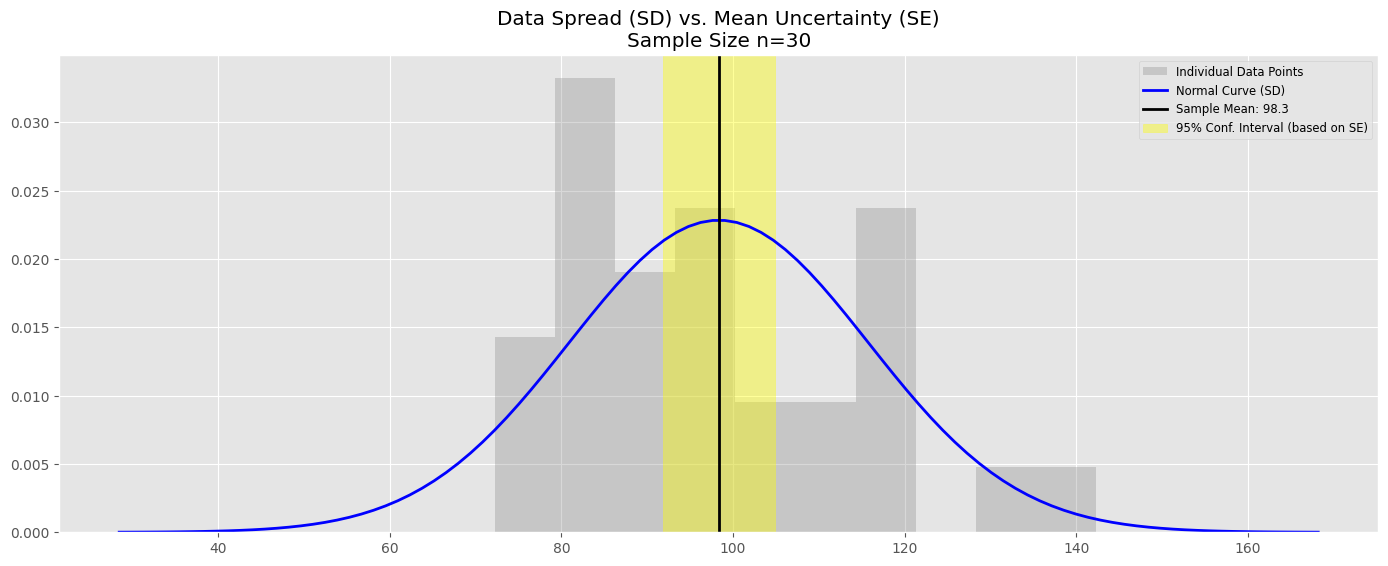

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. The Small Data Example (Base Python Math)
data = [10, 12, 23, 23, 16, 23, 21, 16]
n = len(data)

# Mean
mean_val = sum(data) / n

# Variance (Sample Variance uses n-1)
deviations_sq = [(x - mean_val) ** 2 for x in data]
variance = sum(deviations_sq) / (n - 1)

# Standard Deviation
std_dev = variance**0.5

# Standard Error
std_err = std_dev / (n**0.5)

# 95% Confidence Interval (using t-distribution for small sample)
# Degrees of freedom
df = n - 1
t_critical = stats.t.ppf(0.975, df)  # 0.975 for two-tailed 95%
margin_of_error = t_critical * std_err
ci_lower = mean_val - margin_of_error
ci_upper = mean_val + margin_of_error

print(f"Data: {data}")
print(f"Mean: {mean_val:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Std Dev: {std_dev:.2f}")
print(f"Std Error: {std_err:.2f}")
print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

# 2. Visualization: SD vs SE
# Generate a larger population to show the difference
np.random.seed(42)
population = np.random.normal(loc=100, scale=15, size=10000)

# Sample sizes to test
sample_sizes = [5, 10, 30, 100, 500]
means = []
std_devs = []
std_errors = []

for size in sample_sizes:
    sample = np.random.choice(population, size)
    means.append(np.mean(sample))
    std_devs.append(np.std(sample, ddof=1))
    std_errors.append(np.std(sample, ddof=1) / np.sqrt(size))

# Plotting
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: SD stays relatively constant (it estimates population spread)
ax1.plot(sample_sizes, std_devs, "o-", label="Sample Std Dev", color="blue")
ax1.axhline(y=15, color="red", linestyle="--", label="True Population SD")
ax1.set_xlabel("Sample Size (n)")
ax1.set_ylabel("Spread")
ax1.set_title("Standard Deviation vs. Sample Size\n(Estimates the individual variability)")
ax1.legend()

# Plot 2: SE shrinks as n increases (Law of Large Numbers / precision)
ax2.plot(sample_sizes, std_errors, "s-", label="Standard Error", color="green")
ax2.set_xlabel("Sample Size (n)")
ax2.set_ylabel("Uncertainty of Mean")
ax2.set_title("Standard Error vs. Sample Size\n(Precision of the mean estimate)")
ax2.legend()

plt.tight_layout()
plt.savefig("variance_sd_se_comparison.png")

# Plot 3: Distribution Visualization
plt.clf()
# Take a fixed sample size
n_viz = 30
sample_viz = np.random.choice(population, n_viz)
s_mean = np.mean(sample_viz)
s_std = np.std(sample_viz, ddof=1)
s_se = s_std / np.sqrt(n_viz)
ci = stats.t.interval(0.95, n_viz - 1, loc=s_mean, scale=s_se)

plt.hist(sample_viz, bins=10, alpha=0.3, color="gray", label="Individual Data Points", density=True)
x = np.linspace(s_mean - 4 * s_std, s_mean + 4 * s_std, 100)
plt.plot(x, stats.norm.pdf(x, s_mean, s_std), color="blue", lw=2, label="Normal Curve (SD)")

# Mark Mean and SE/CI
plt.axvline(s_mean, color="black", lw=2, label=f"Sample Mean: {s_mean:.1f}")
plt.axvspan(ci[0], ci[1], color="yellow", alpha=0.4, label="95% Conf. Interval (based on SE)")

plt.title(f"Data Spread (SD) vs. Mean Uncertainty (SE)\nSample Size n={n_viz}")
plt.legend(fontsize="small")
plt.savefig("distribution_and_ci.png")